In [1]:
#importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

from math import sqrt


In [2]:
#wczytyuje dane + cechy
bike_data = pd.read_csv(r"C:\Users\monia\OneDrive\Pulpit\13.5Regresja w praktyce-pozostale metryki\daily-bike-share.csv")


numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
target = 'rentals'

bike_data.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


In [3]:
#pierwszy model LinearRegression
X = bike_data[['temp']]
y = bike_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [4]:
#trenowanie pierwszego modelu
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
#predykcja
y_pred_test_1 = lr_model.predict(X_test)

print("MODEL 1 — LinearRegression (temp)")
print("R²:", r2_score(y_test, y_pred_test_1))
print("MAE:", mean_absolute_error(y_test, y_pred_test_1))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_test_1))
print("MSE:", mean_squared_error(y_test, y_pred_test_1))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred_test_1)))


MODEL 1 — LinearRegression (temp)
R²: 0.19412301357953676
MAE: 391.02879410802956
MAPE: 2.9864925318560496
MSE: 397066.9447179113
RMSE: 630.1324818781454


In [7]:
#dane do ostatniego modelu
X = bike_data[numeric_features + categorical_features]
y = bike_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [10]:
#Pipeline
numeric_transformer = Pipeline(steps=[
    ('power', PowerTransformer()),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)



In [11]:
# Pipeline + ElasticNet
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet())
])



In [12]:
# GRidSearch
cv = TimeSeriesSplit(n_splits=5)

params = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4, 5],
    'regressor__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': np.arange(0, 1.1, 0.1)
}

grid = GridSearchCV(
    final_pipeline,
    params,
    scoring='neg_mean_squared_error',
    cv=cv
)

grid.fit(X_train, y_train)
print("Najlepsze parametry:", grid.best_params_)




C:\Users\monia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.282e+06, tolerance: 9.103e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\monia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.539e+06, tolerance: 6.547e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

Najlepsze parametry: {'preprocessor__num__poly__degree': 2, 'regressor__alpha': 1.0, 'regressor__l1_ratio': np.float64(1.0)}


C:\Users\monia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.465e+04, tolerance: 1.749e+04
  model = cd_fast.enet_coordinate_descent(


In [13]:
# predykcja modelu końcowego
final_model = grid.best_estimator_
y_pred_test_final = final_model.predict(X_test)

print("MODEL OSTATECZNY = Pipeline i ElasticNet")
print("R2:", r2_score(y_test, y_pred_test_final))
print("MAE:", mean_absolute_error(y_test, y_pred_test_final))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_test_final))
print("MSE:", mean_squared_error(y_test, y_pred_test_final))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred_test_final)))



MODEL OSTATECZNY = Pipeline i ElasticNet
R2: 0.5764184999526181
MAE: 343.9747215407251
MAPE: 1.3587501370268111
MSE: 208704.5726543321
RMSE: 456.8419558822636


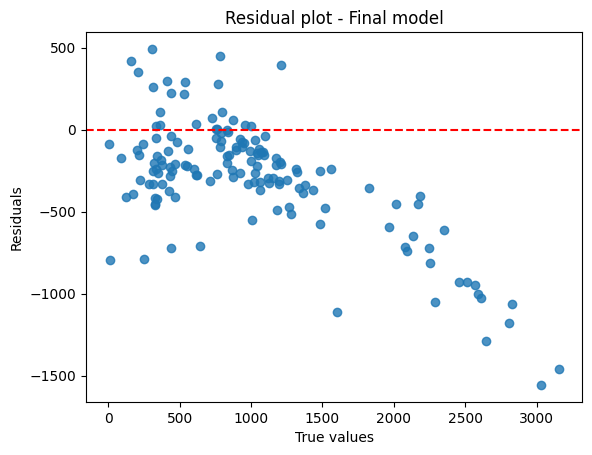

In [14]:
# Residual plot
errors_final = y_pred_test_final - y_test

plt.scatter(y_test, errors_final, alpha=0.8)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual plot - Final model")
plt.xlabel("True values")
plt.ylabel("Residuals")
plt.show()


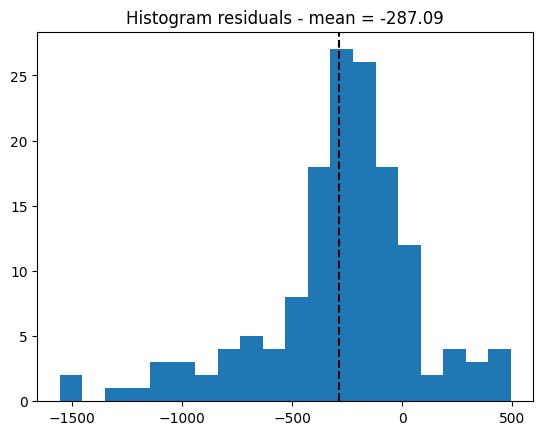

In [15]:
# Histogram residuals
plt.hist(errors_final, bins=20)
plt.axvline(errors_final.mean(), color='k', linestyle='dashed')
plt.title(f"Histogram residuals - mean = {errors_final.mean():.2f}")
plt.show()




In [16]:
# Porównanie modeli
comparison = pd.DataFrame({
    'Model': ['Model 1 — LinearRegression', 'Model końcowy — Pipeline + ElasticNet'],
    'R2': [r2_score(y_test, y_pred_test_1), r2_score(y_test, y_pred_test_final)],
    'RMSE': [sqrt(mean_squared_error(y_test, y_pred_test_1)), sqrt(mean_squared_error(y_test, y_pred_test_final))],
    'MAE': [mean_absolute_error(y_test, y_pred_test_1), mean_absolute_error(y_test, y_pred_test_final)],
    'MAPE': [mean_absolute_percentage_error(y_test, y_pred_test_1), mean_absolute_percentage_error(y_test, y_pred_test_final)]
})

comparison




,Model,R2,RMSE,MAE,MAPE
0,Model 1 — LinearRegression,0.194123,630.132482,391.028794,2.986493
1,Model końcowy — Pipeline + ElasticNet,0.576418,456.841956,343.974722,1.358750
